<a href="https://colab.research.google.com/github/mahmudscode/NLP_work/blob/main/NLP_WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

# Define the target path
target_path = '/content/drive/MyDrive/LLM_BANGLA_DATA/Bangla_newspaper'

# Change the current working directory
os.chdir(target_path)

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/LLM_BANGLA_DATA/Bangla_newspaper


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Bidirectional,
    LSTM
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
import os

for file in os.listdir():
    print(file)

data
data_v2


In [5]:
import os

for root, dirs, files in os.walk("data_v2"):
    print(f"\nFolder: {root}")
    print("Files:", files[:5])
    break


Folder: data_v2
Files: ['data_v2.json']


In [6]:
import os

for root, dirs, files in os.walk("data_v2"):
    if len(files) > 0:
        print("Example file:", os.path.join(root, files[0]))
        break

Example file: data_v2/data_v2.json


In [5]:
import json

with open("data_v2/data_v2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))

<class 'list'>


In [8]:
print(len(data))

408471


In [9]:
data[0]

{'author': 'গাজীপুর প্রতিনিধি',
 'category': 'bangladesh',
 'category_bn': 'বাংলাদেশ',
 'published_date': '০৪ জুলাই ২০১৩, ২৩:২৬',
 'modification_date': '০৪ জুলাই ২০১৩, ২৩:২৭',
 'tag': ['গাজীপুর'],
 'comment_count': 0,
 'title': 'কালিয়াকৈরে টিফিন খেয়ে ৫০০ শ্রমিক অসুস্থ, বিক্ষোভ',
 'url': 'http://www.prothom-alo.com/bangladesh/article/19030',
 'content': 'গাজীপুরের কালিয়াকৈর উপজেলার তেলিরচালা এলাকায় আজ বৃহস্পতিবার রাতের টিফিন খেয়ে একটি পোশাক কারখানার ৫০০ শ্রমিক অসুস্থ হয়ে পড়েছেন। এ ঘটনায় বিক্ষোভ করেছেন ওই কারখানার শ্রমিকেরা।সফিপুর মডার্ন হাসপাতালের জরুরি বিভাগের চিকিত্সক আল আমিন প্রথম আলো ডটকমকে বলেন, খাদ্যে বিষক্রিয়ায় তাঁরা (শ্রমিকেরা) অসুস্থ হয়ে পড়েছেন। এতে আতঙ্কিত হওয়ার কিছু নেই। অসুস্থদের চিকিত্সা দেওয়া হয়েছে।কারখানার শ্রমিক ও পুলিশ সূত্রে জানা যায়, উপজেলার তেলিরচালা এলাকার সেজাদ সোয়েটার লিমিটেড কারখানার শ্রমিকদের আজ রাত সাড়ে সাতটার দিকে টিফিন দেওয়া হয়। টিফিনে ছিল ডিম, রুটি, পেটিস ও কলা। টিফিন খেয়ে শ্রমিকেরা যথারীতি কাজে যোগ দেন। ওই টিফিন খাওয়ার প্রায় এক ঘণ্টা 

In [4]:
import json
import pandas as pd

file_path = "data_v2/data_v2.json"

def data_generator():
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

        for item in data:
            yield {
                "text": str(item.get("title", "")) + " " + str(item.get("content", "")),
                "category": item.get("category", "")
            }

# Take only sample first (VERY IMPORTANT for Colab)
sample_size = 100000

records = []
for i, item in enumerate(data_generator()):
    records.append(item)

    if i + 1 >= sample_size:
        break

df = pd.DataFrame(records)

print(df.shape)
df.head()

(100000, 2)


,text,category
0,"কালিয়াকৈরে টিফিন খেয়ে ৫০০ শ্রমিক অসুস্থ, বিক...",bangladesh
1,সেমিফাইনাল বাধাও পেরিয়ে গেলেন লিসিকি এবারের উ...,sports
2,সংসদে খালেদার অভিযোগের জবাব দিয়েছে ভারত জাতীয...,bangladesh
3,পাসওয়ার্ড ভুলে যান! সহজ পাসওয়ার্ডের কারণে অন...,technology
4,চলে গেলেন মাউস উদ্ভাবক কম্পিউটার মাউসের উদ্ভাব...,technology


In [7]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"[^\u0980-\u09FF\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["category"])

print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'bangladesh': np.int64(0), 'economy': np.int64(1), 'education': np.int64(2), 'entertainment': np.int64(3), 'international': np.int64(4), 'life-style': np.int64(5), 'opinion': np.int64(6), 'sports': np.int64(7), 'technology': np.int64(8)}


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 50000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 400

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(X_train_pad.shape)

(85000, 400)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

cnn_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(encoder.classes_), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
cnn_history = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128
)

Epoch 1/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9956 - loss: 0.0162 - val_accuracy: 0.9409 - val_loss: 0.3105
Epoch 2/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9966 - loss: 0.0135 - val_accuracy: 0.9391 - val_loss: 0.3462
Epoch 3/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.9382 - val_loss: 0.3821
Epoch 4/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9378 - val_loss: 0.3625
Epoch 5/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.9386 - val_loss: 0.3739


In [28]:
bilstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Bidirectional(LSTM(64, dropout=0.3)),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(encoder.classes_), activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64
)

Epoch 1/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 46s 36ms/step - accuracy: 0.8079 - loss: 0.6388 - val_accuracy: 0.8992 - val_loss: 0.3210
Epoch 2/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9227 - loss: 0.2673 - val_accuracy: 0.9169 - val_loss: 0.2779
Epoch 3/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9580 - loss: 0.1512 - val_accuracy: 0.9114 - val_loss: 0.3505
Epoch 4/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9731 - loss: 0.0960 - val_accuracy: 0.9271 - val_loss: 0.3320
Epoch 5/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9818 - loss: 0.0668 - val_accuracy: 0.9214 - val_loss: 0.3972


In [32]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    Attention
)

from tensorflow.keras.models import Model

In [33]:
inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=MAX_WORDS,
    output_dim=128
)(inputs)

bilstm = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3
    )
)(embedding)

attention = Attention()(
    [bilstm, bilstm]
)

pool = GlobalAveragePooling1D()(attention)

dense = Dense(
    64,
    activation='relu'
)(pool)

drop = Dropout(0.5)(dense)

outputs = Dense(
    len(encoder.classes_),
    activation='softmax'
)(drop)

attention_model = Model(
    inputs=inputs,
    outputs=outputs
)

attention_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 400, 128)  │  6,400,000 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 400, 128)  │     98,816 │ embedding_5[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 400, 128)  │          0 │ bidirectional_4[… │
│ (Attention)         │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_2[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 9)         │        585 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,507,657 (24.82 MB)

 Trainable params: 6,507,657 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_attention_model.keras",
        save_best_only=True
    )
]

In [36]:
history = attention_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.8048 - loss: 0.6257 - val_accuracy: 0.9262 - val_loss: 0.2578 - learning_rate: 0.0010
Epoch 2/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.9449 - loss: 0.1962 - val_accuracy: 0.9341 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 3/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9707 - loss: 0.1044 - val_accuracy: 0.9367 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 4/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.9822 - loss: 0.0638 - val_accuracy: 0.9400 - val_loss: 0.2773 - learning_rate: 0.0010
Epoch 5/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 52s 44ms/step - accuracy: 0.9872 - loss: 0.0434 - val_accuracy: 0.9424 - val_loss: 0.2972 - learning_rate: 0.0010
Epoch 6/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 52s 44ms/step - accuracy: 0.9948 - loss: 0.0204 - val_accuracy: 0.9415 - val_loss: 0.3482 - learning_rate: 5.0000e-04


In [37]:
loss, accuracy = attention_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {accuracy:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9413 - loss: 0.1925
Test Accuracy: 0.9413


In [38]:
predictions = attention_model.predict(
    X_test_pad
)

y_pred = predictions.argmax(axis=1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

               precision    recall  f1-score   support

   bangladesh       0.97      0.96      0.97      8448
      economy       0.81      0.79      0.80       589
    education       0.93      0.91      0.92       498
entertainment       0.94      0.94      0.94      1053
international       0.93      0.92      0.92      1131
   life-style       0.83      0.80      0.82       368
      opinion       0.73      0.88      0.80       486
       sports       0.98      0.98      0.98      1840
   technology       0.86      0.88      0.87       587

     accuracy                           0.94     15000
    macro avg       0.89      0.90      0.89     15000
 weighted avg       0.94      0.94      0.94     15000



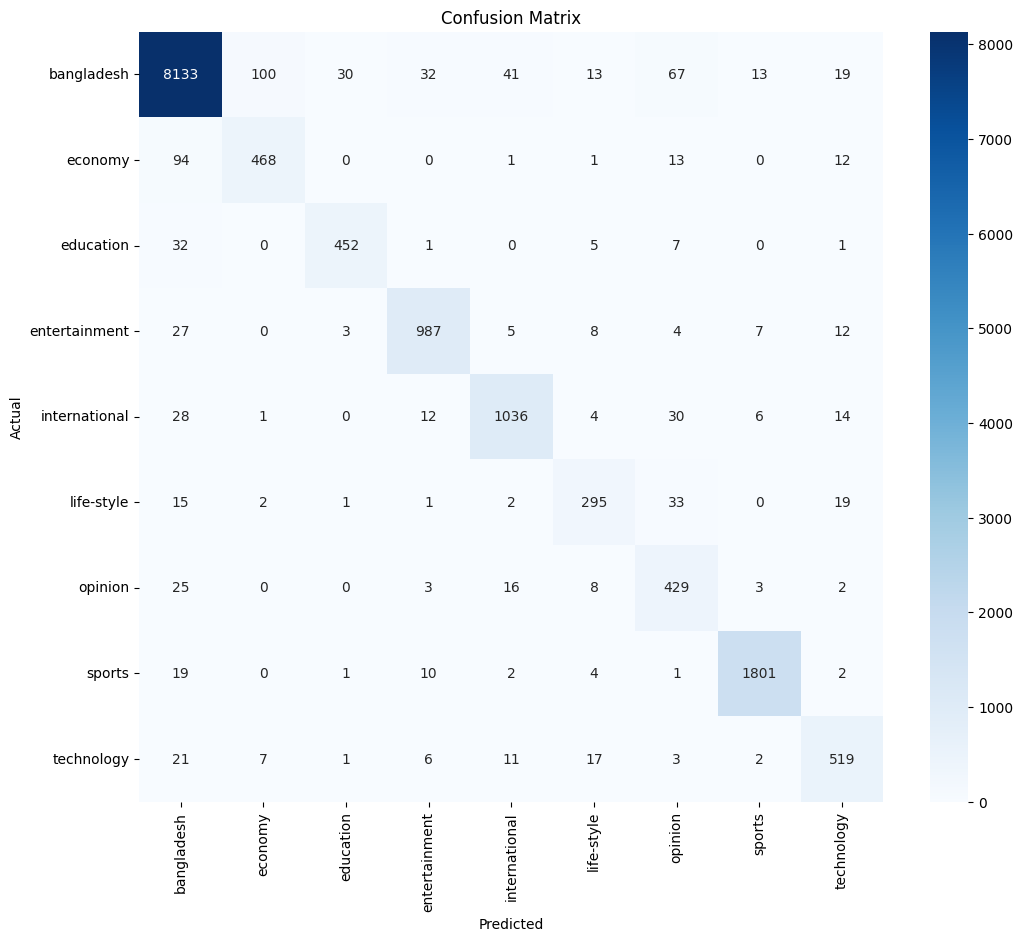

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

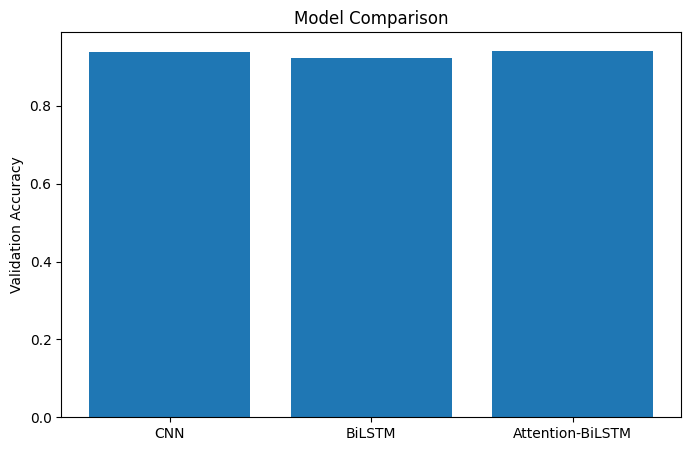

In [41]:
models = [
    "CNN",
    "BiLSTM",
    "Attention-BiLSTM"
]

accuracies = [
    cnn_history.history['val_accuracy'][-1],
    bilstm_model.history.history['val_accuracy'][-1] if hasattr(bilstm_model, 'history') else 0,
    history.history['val_accuracy'][-1]
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")

plt.show()

In [42]:
attention_model.save(
    "/content/drive/MyDrive/attention_bilstm_bangla.keras"
)

In [43]:
import pickle

with open(
    "/content/drive/MyDrive/tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )